In [1]:
from circuit_benchmarks import MCMR_Crosstalk_Experiment
#
from selene_sim import DepolarizingErrorModel, Stim, Quest
from pecos_selene import PecosGeneralErrorModel
from collections import Counter
from hugr.qsystem.result import QsysResult
from selene_sim import build, Stim
from pecos_selene import qsystem_model_alpha
from selene_anduril import AndurilRuntimePlugin as AndurilRuntime
from selene_sim import SimpleLeakageErrorModel
from selene_eldarion import register_eldarion, QtmPlatformPlugin
register_eldarion()

In [2]:
# index of focus qubit(s) that receives repeated MCMR.  Must be chosen from the zone qubits (q[0:15]) .  
focus_qubits = [0]
seq_lengths = [1, 100] #  intermediate shot lengths needed to resolve possible quadratic dependencies (memory error).
mode = 'Reset' # MCMR, MCM, or Reset.  Running MCM requires qtm_platform-v0.5.5. comment out in mcmr_crosstalk.py if you don't have it.
device_name = 'Helios-1E'

# datetime labelling ensures that the pickle filename is unique and informative.
import datetime
x = datetime.datetime.now()
filename = f'./exp_{mode}_Crosstalk_q{focus_qubits}_{x}.p'
print(filename)

exp = MCMR_Crosstalk_Experiment(focus_qubits, seq_lengths, mode, device_name = device_name, filename=filename)
exp.options['measure_leaked'] = False # False by default.
exp.add_settings()

./exp_Reset_Crosstalk_q[0]_2026-05-06 11:57:13.095850.p


In [13]:
# or load MCMR crosstalk experiment


filename = f'./<your filename>.p'
exp = MCMR_Crosstalk_Experiment.load(filename)

In [3]:
# simulate locally

shots = 100 # 1000
simulator = Stim()
error_model = PecosGeneralErrorModel()


exp.sim(shots, error_model = error_model, simulator=simulator)

Simulating ...


HugrReadError: Error loading HUGR package.

Caused by:
    0: failed to import hugr generated by guppylang (guppylang-internals-v0.34.0)-v0.21.13
    1: import failed in context: `define-func` node with id 0
    2: import failed in context: symbol `mcmr_crosstalk.MCMR_Crosstalk_Experiment.make_circuit.<locals>.main` defined by node 0
    3: import failed in context: function body defined by region with id 1
    4: import failed in context: `cfg` node with id 22
    5: import failed in context: `block` node with id 25
    6: import failed in context: term 35 as `Type`
    7: extension error
    8: Importing the hugr requires extension collections.borrow_arr, which was not found in the registry. The available extensions are: [arithmetic.conversions, arithmetic.float, arithmetic.float.types, arithmetic.int, arithmetic.int.types, collections.array, collections.list, collections.static_array, collections.value_array, logic, prelude, ptr, qtm.platform, tket.bool, tket.futures, tket.gpu, tket

In [3]:
# or submit to nexus
import qnexus
qnexus.login_with_credentials()

Already logged in. Tokens are valid.


In [4]:
from quantinuum_schemas.models.backend_config import QuantinuumCompilerOptions

project = qnexus.projects.get_or_create(name="MCMR-crosstalk-project-example")
qnexus.context.set_active_project(project)


# configuration for simulation
n_qubits = exp.n_qubits
backend_config = qnexus.QuantinuumConfig(device_name=device_name, simulator='stabilizer', max_cost=1000000,compiler_options={'max-qubits': n_qubits})

# configuration for hardware
# priority = 'high'
# priority = 'low'
# compiler_options = QuantinuumCompilerOptions(priority=priority)
# backend_config = qnexus.QuantinuumConfig(device_name='Helios-1', compiler_options=compiler_options, max_cost=1000000)

In [5]:
# submit

shots = 10 #1000 # the Helios-1 benchmark was for 1000 shots on the hardware
execute_job_ref = exp.submit(shots, backend_config)

Experiment saved! ./exp_Reset_Crosstalk_q[0]_2026-05-06 11:57:13.095850.p


In [12]:
# inspect status of the execution job

qnexus.jobs.status(execute_job_ref)

JobStatus(status=<JobStatusEnum.COMPLETED: 'COMPLETED'>, message='The job is completed.', error_detail=None, completed_time=datetime.datetime(2026, 5, 6, 17, 58, 4, 798483, tzinfo=datetime.timezone.utc), queued_time=datetime.datetime(2026, 5, 6, 17, 57, 43, 529320, tzinfo=datetime.timezone.utc), submitted_time=datetime.datetime(2026, 5, 6, 17, 57, 33, 310000, tzinfo=datetime.timezone.utc), running_time=datetime.datetime(2026, 5, 6, 17, 57, 48, 690732, tzinfo=datetime.timezone.utc), cancelled_time=None, error_time=None, queue_position=None, cost=30.64)

In [13]:
# retrieve results

exp.retrieve(execute_job_ref)

Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `U1q`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `ZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `U1q`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `ZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will om

Experiment saved! ./exp_Reset_Crosstalk_q[0]_2026-05-06 11:57:13.095850.p


Global per Reset Crosstalk Infidelity (1e-4):  0.241448 +/- 1.662939
Global per Reset Crosstalk Error Channel p(1|0) (1e-4):  0.103069 +/- 2.419547
Global per Reset Crosstalk Error Channel p(0|1) (1e-4):  0.618414 +/- 2.426074
Global per Reset Crosstalk Error Channel p(L|0) (1e-4):  0.000954 +/- 1.709337
Global per Reset Crosstalk Error Channel p(L|1) (1e-4):  0.000954 +/- 1.709337


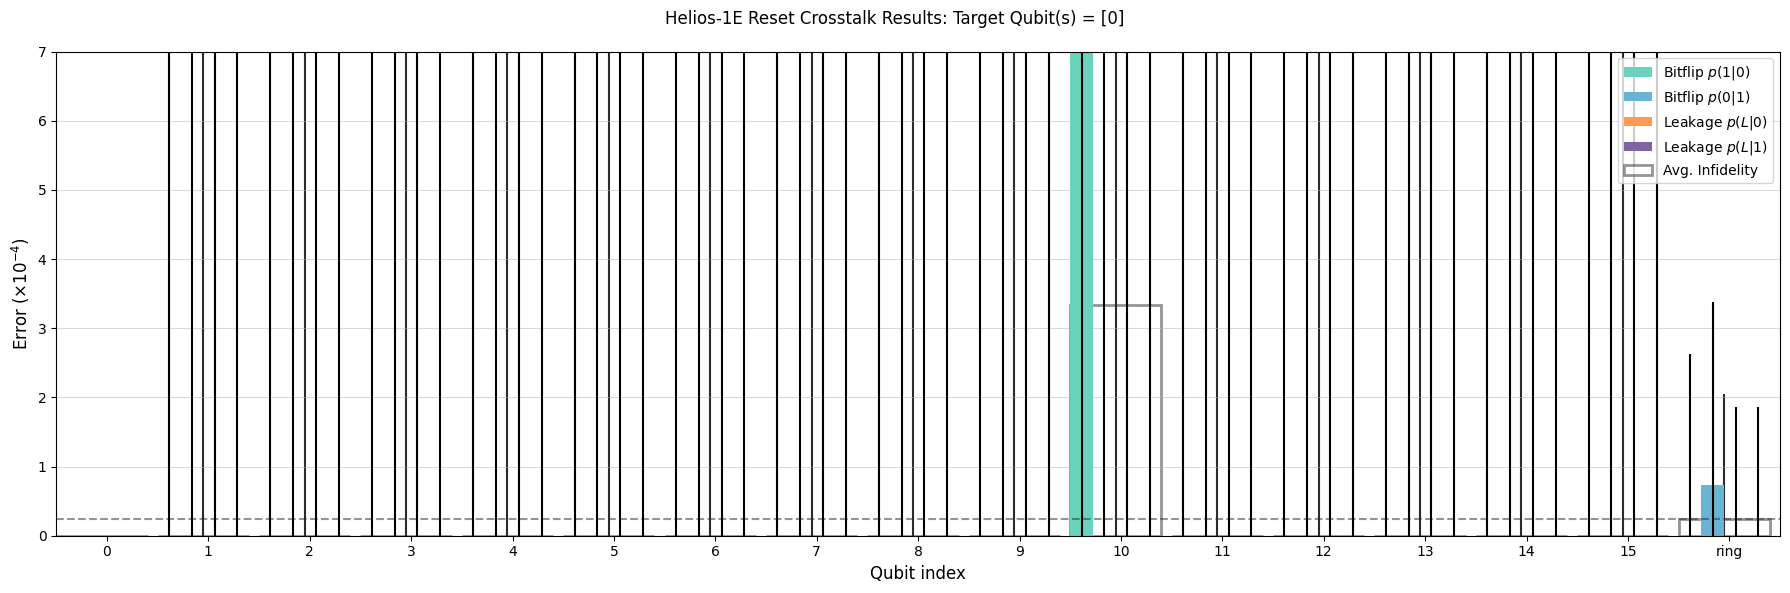

In [14]:
# analyze experimental results

exp.analyze_results(save=False, verbose=True)

In [15]:
# save experiment object to working directory

exp.save()

Experiment saved! ./exp_MCMR_Crosstalk_q[0, 2, 4, 6, 8, 10, 12, 14]_2026-04-28 16:02:41.765289.p


In [7]:
from qtm_platform.ops import dirty_measure

In [13]:
help(dirty_measure)

Help on GuppyFunctionDefinition in module guppylang.defs object:

class GuppyFunctionDefinition(GuppyDefinition, typing.Generic)
 |  GuppyFunctionDefinition(wrapped: guppylang_internals.definition.common.Definition) -> None
 |
 |  A Guppy function definition.
 |
 |  Method resolution order:
 |      GuppyFunctionDefinition
 |      GuppyDefinition
 |      guppylang_internals.tracing.object.TracingDefMixin
 |      guppylang_internals.tracing.object.DunderMixin
 |      typing.Generic
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __call__(self, *args: P.args, **kwargs: P.kwargs) -> ~Out
 |      Call self as a function.
 |
 |  __delattr__(self, name)
 |      Implement delattr(self, name).
 |
 |  __eq__(self, other)
 |      Return self==value.
 |
 |  __hash__(self)
 |      Return hash(self).
 |
 |  __init__(self, wrapped: guppylang_internals.definition.common.Definition) -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __repr__(self)
 |      

In [9]:
help(dirty_measure)

Help on GuppyFunctionDefinition in module guppylang.defs object:

class GuppyFunctionDefinition(GuppyDefinition, typing.Generic)
 |  GuppyFunctionDefinition(wrapped: guppylang_internals.definition.common.Definition) -> None
 |
 |  A Guppy function definition.
 |
 |  Method resolution order:
 |      GuppyFunctionDefinition
 |      GuppyDefinition
 |      guppylang_internals.tracing.object.TracingDefMixin
 |      guppylang_internals.tracing.object.DunderMixin
 |      typing.Generic
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __call__(self, *args: P.args, **kwargs: P.kwargs) -> ~Out
 |      Call self as a function.
 |
 |  __delattr__(self, name)
 |      Implement delattr(self, name).
 |
 |  __eq__(self, other)
 |      Return self==value.
 |
 |  __hash__(self)
 |      Return hash(self).
 |
 |  __init__(self, wrapped: guppylang_internals.definition.common.Definition) -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __repr__(self)
 |      

In [10]:
import qtm_platform.ops

In [ ]:
qtm_platform.ops.